In [1]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [2]:
# Create dictionary with dataframes for each dataset
tscil_results = {}

# UCI-HAR
tscil_results['HAR'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.8, 89.1],
    'Avg End Acc error': [19.7, 6.1],
    'Avg End Fgt': [22.1, 13.2],
    'Avg End Fgt error': [37.2, 11.4],
    'Avg Cur Acc': [87.2, 97.8],
    'Avg Cur Acc error': [10.4, 1.9]
})

# UWave
tscil_results['UWAVE'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.7, 83.2],
    'Avg End Acc error': [2.7, 3.5],
    'Avg End Fgt': [33.6, 20.3],
    'Avg End Fgt error': [3.4, 4.5],
    'Avg Cur Acc': [97.9, 98.4],
    'Avg Cur Acc error': [0.5, 0.4]
})

# DSA
tscil_results['DSA'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [79.6, 96.9],
    'Avg End Acc error': [15.6, 2.2],
    'Avg End Fgt': [23.6, 3.7],
    'Avg End Fgt error': [19.2, 2.7],
    'Avg Cur Acc': [89.9, 100.0],
    'Avg Cur Acc error': [9.6, 0.1]
})

# GRABMyo
tscil_results['GRABMYO'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [46.5, 55.9],
    'Avg End Acc error': [3.2, 5.1],
    'Avg End Fgt': [35.0, 49.4],
    'Avg End Fgt error': [5.7, 5.0],
    'Avg Cur Acc': [73.7, 95.4],
    'Avg Cur Acc error': [4.7, 1.3]
})

# WISDM
tscil_results['WISDM'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [41.7, 51.6],
    'Avg End Acc error': [5.0, 13.7],
    'Avg End Fgt': [27.9, 53.1],
    'Avg End Fgt error': [12.4, 14.3],
    'Avg Cur Acc': [60.7, 95.8],
    'Avg Cur Acc error': [10.2, 2.0]
})

In [3]:
AL_SETUP = {
    'HAR': (3,300),
    'UWAVE' : (3,25),
    'GRABMYO': (6,20),
    'WISDM': (5,40)
}

In [4]:
DATASET = 'GRABMYO'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [5]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

show_filter = ['uncertainty-margin', 'typiclust' ,'coreset', 'random']
colfilter = ['task', 'cycle', 'index', 
            'Random-ER', 'Random-ASER',
            'Uncertainty-margin-ER', 'Uncertainty-margin-ASER',
            'TypiClust-ER', 'TypiClust-ASER',
            'CoreSet-ER', 'CoreSet-ASER',
            ]

filtered_files = [f for f in filtered_files if not 'TypiClustScore-' in f]


Filtered Files:	 ['grabmyo/TypiClust_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-lc_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/TypiClustLimit_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Kmeans-ppp_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/CoreSetProb_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-lc_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Random_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/TypiClust_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-margin_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/TypiClustLimit_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Random_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-margin_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/TypiCore_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-entropy_ASER_cycle_6_per_20_grabmyo.csv', 'grabmyo/Uncertainty-entropy_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/CoreSetProb_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/CoreSet_ER_cycle_6_per_20_grabmyo.csv', 'grabmyo/CoreSet_ASER_cycle_6_per_20_grabmyo.

## Diversity and Random

In [6]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', show_filter, AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-margin-ER,CoreSetProb-ASER,Uncertainty-margin-ASER,CoreSetProb-ER,TypiClustLimit-ASER,TypiClust-ER,Random-ER,Random-ASER,CoreSet-ASER,TypiClustLimit-ER,CoreSet-ER,TypiClust-ASER
0,0,0,0,73.73,70.97,73.73,70.97,69.73,72.03,73.73,73.73,64.12,69.73,64.12,72.03
1,0,1,1,75.78,75.01,75.78,75.01,77.37,76.06,75.87,75.87,68.57,77.37,68.57,76.06
2,0,2,2,77.51,77.10,77.51,77.10,79.00,81.08,76.64,76.64,72.94,79.00,72.94,81.08
3,0,3,3,79.57,80.49,79.57,80.49,81.41,82.84,77.92,77.92,75.43,81.41,75.43,82.84
4,0,4,4,80.01,86.09,80.01,86.09,81.99,86.38,81.14,81.14,79.46,81.99,79.46,86.38
5,0,5,5,81.22,86.59,81.22,86.59,82.89,86.62,82.74,82.74,80.96,82.89,80.96,86.62
6,1,0,6,56.49,52.99,51.15,56.57,56.69,55.05,55.24,51.67,53.98,57.55,63.89,54.17
7,1,1,7,58.23,53.64,50.17,59.99,55.75,55.39,55.78,53.06,57.78,58.52,72.14,54.79
8,1,2,8,58.85,63.36,55.24,60.66,53.88,58.51,55.01,52.26,62.40,59.20,77.11,54.48
9,1,3,9,58.13,68.45,56.35,60.85,50.75,56.96,56.45,60.59,64.51,56.53,79.38,53.27


In [7]:
uncert_la.columns

Index(['task', 'cycle', 'index', 'Uncertainty-margin-ER', 'CoreSetProb-ASER',
       'Uncertainty-margin-ASER', 'CoreSetProb-ER', 'TypiClustLimit-ASER',
       'TypiClust-ER', 'Random-ER', 'Random-ASER', 'CoreSet-ASER',
       'TypiClustLimit-ER', 'CoreSet-ER', 'TypiClust-ASER'],
      dtype='object')

In [8]:
uncert_la = uncert_la[colfilter]
uncert_la

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER
0,0,0,0,73.73,73.73,73.73,73.73,72.03,72.03,64.12,64.12
1,0,1,1,75.87,75.87,75.78,75.78,76.06,76.06,68.57,68.57
2,0,2,2,76.64,76.64,77.51,77.51,81.08,81.08,72.94,72.94
3,0,3,3,77.92,77.92,79.57,79.57,82.84,82.84,75.43,75.43
4,0,4,4,81.14,81.14,80.01,80.01,86.38,86.38,79.46,79.46
5,0,5,5,82.74,82.74,81.22,81.22,86.62,86.62,80.96,80.96
6,1,0,6,55.24,51.67,56.49,51.15,55.05,54.17,63.89,53.98
7,1,1,7,55.78,53.06,58.23,50.17,55.39,54.79,72.14,57.78
8,1,2,8,55.01,52.26,58.85,55.24,58.51,54.48,77.11,62.40
9,1,3,9,56.45,60.59,58.13,56.35,56.96,53.27,79.38,64.51


['Random-ER', 'Random-ASER']


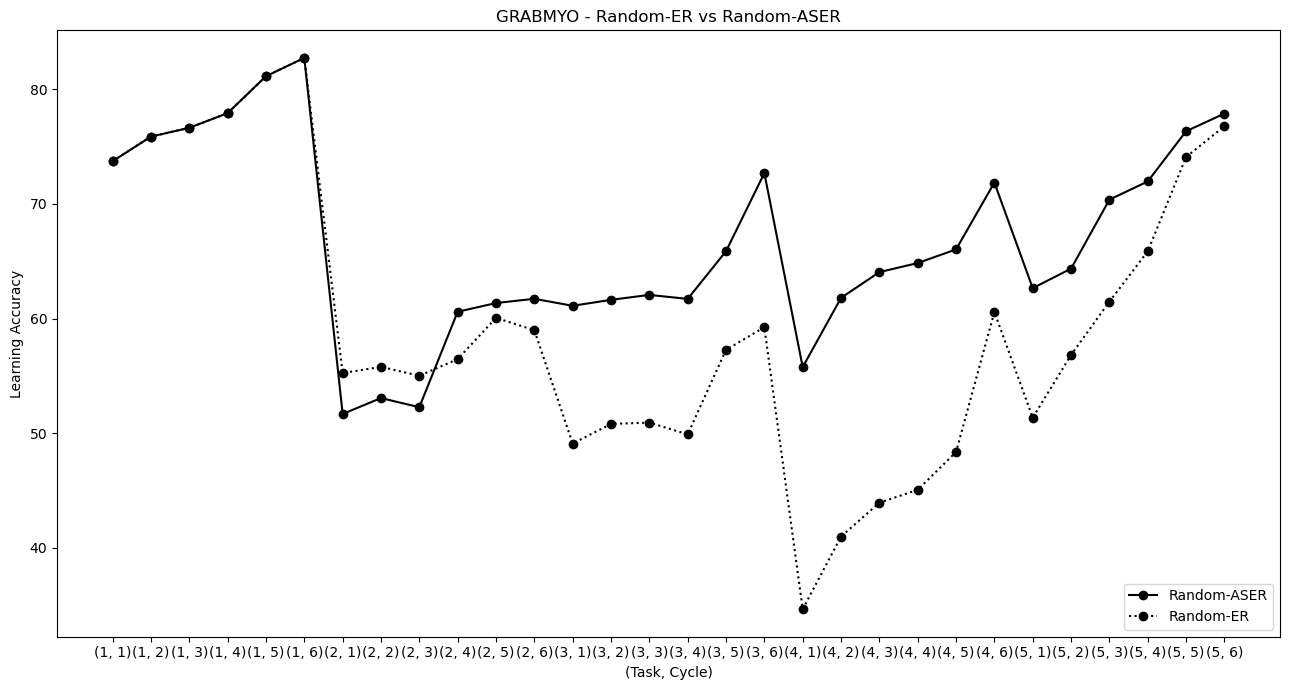

In [9]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER']


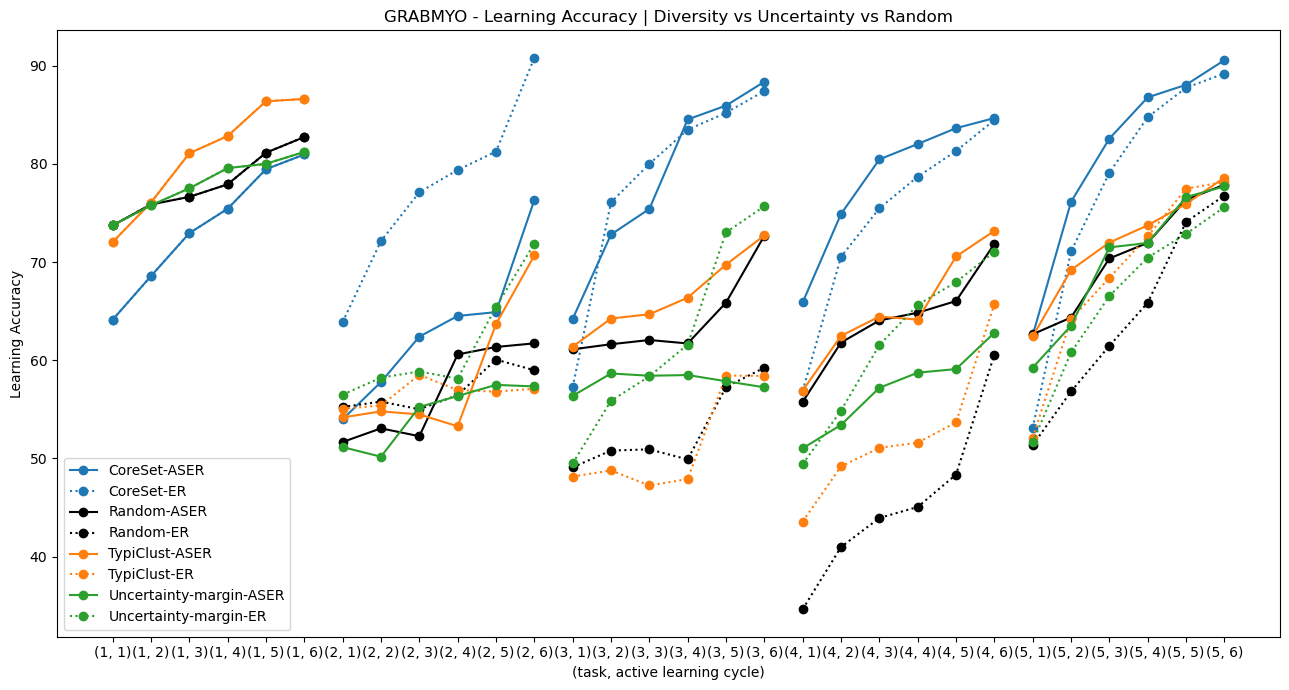

In [10]:
pu.plot_progress(
    df=uncert_la, 
    loc='best',
    title=f"{DATASET} - Learning Accuracy | Diversity vs Uncertainty vs Random",
    X_label="(task, active learning cycle)", 
    Y_label="Learning Accuracy",
    break_between_tasks=True
    )

In [11]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', show_filter, AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)
uncert_aa = uncert_aa[colfilter]

['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER']


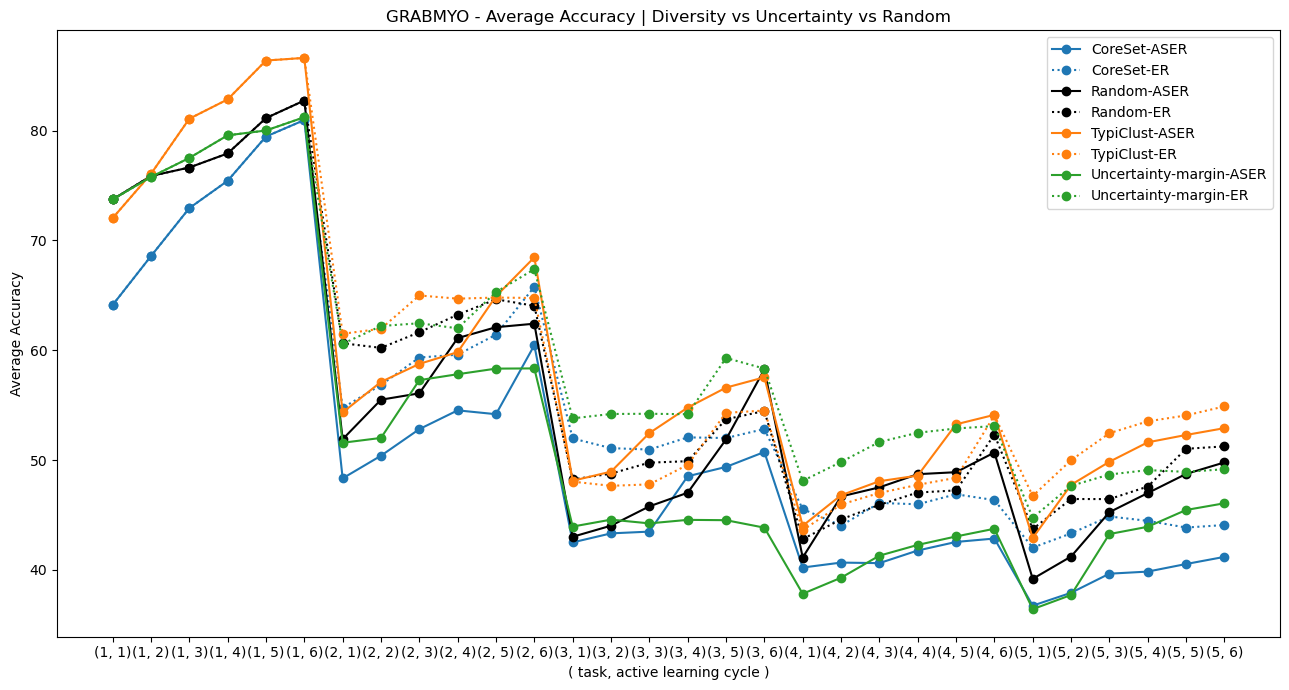

In [12]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Average Accuracy | Diversity vs Uncertainty vs Random",
    X_label="( task, active learning cycle )", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


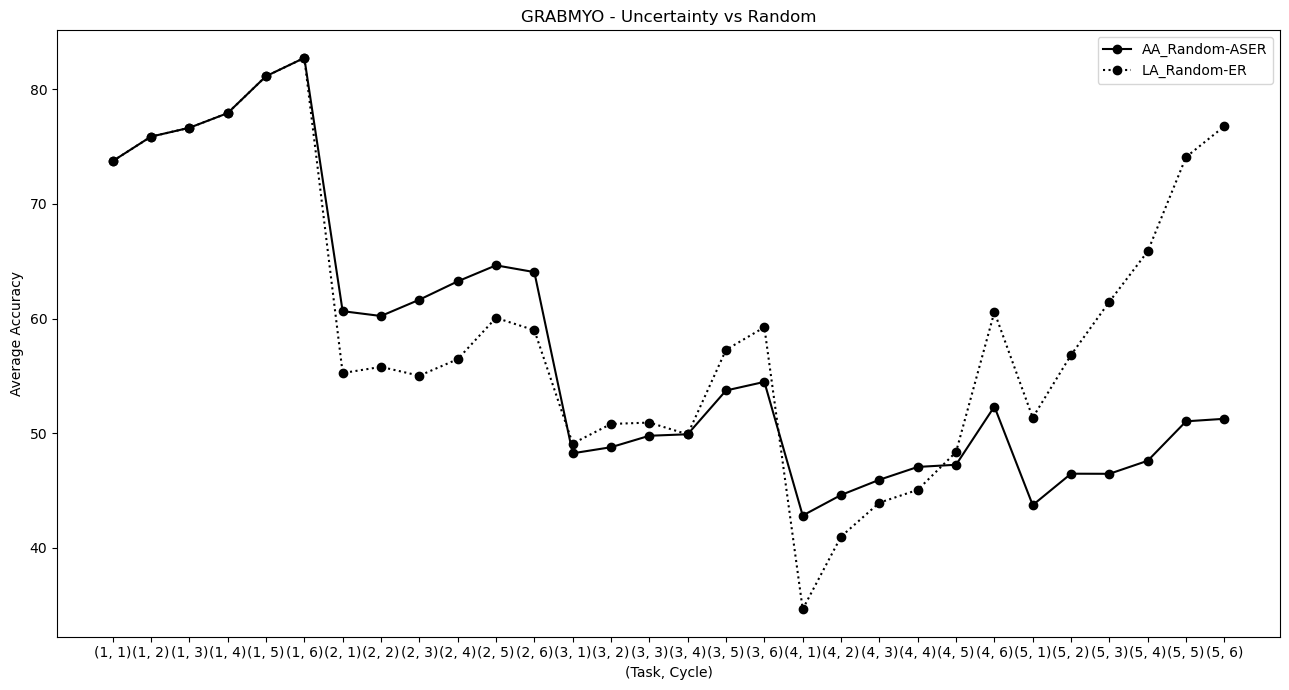

In [13]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [14]:
uncer_aa_task = pu.task_level_filter(uncert_aa) #.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER
0,0,5,5,82.74,82.74,81.22,81.22,86.62,86.62,80.96,80.96
1,1,5,11,64.05,62.42,67.38,58.35,64.76,68.46,65.78,60.46
2,2,5,17,54.47,58.27,58.33,43.85,54.51,57.54,52.83,50.74
3,3,5,23,52.32,50.69,53.10,43.75,54.07,54.12,46.36,42.86
4,4,5,29,51.25,49.79,49.17,46.07,54.89,52.91,44.09,41.19


['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER']


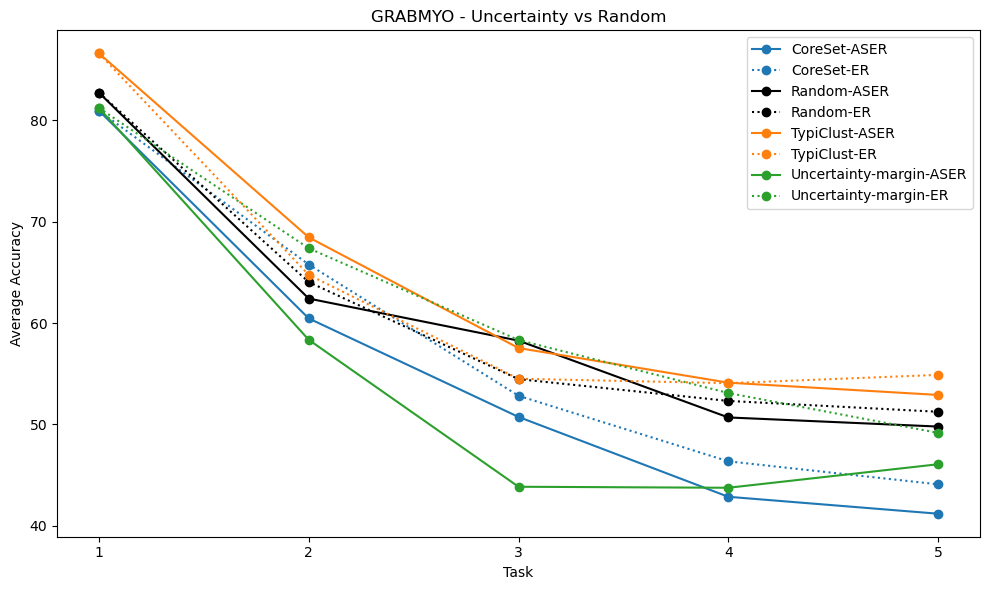

In [15]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [16]:
uncer_la_task = pu.task_level_filter(uncert_la) #.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER
0,0,5,5,82.74,82.74,81.22,81.22,86.62,86.62,80.96,80.96
1,1,5,11,58.98,61.72,71.88,57.33,57.10,70.67,90.80,76.32
2,2,5,17,59.24,72.69,75.69,57.24,58.40,72.71,87.43,88.37
3,3,5,23,60.57,71.86,71.05,62.80,65.72,73.18,84.47,84.67
4,4,5,29,76.78,77.88,75.60,77.71,78.15,78.60,89.21,90.57


['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER']


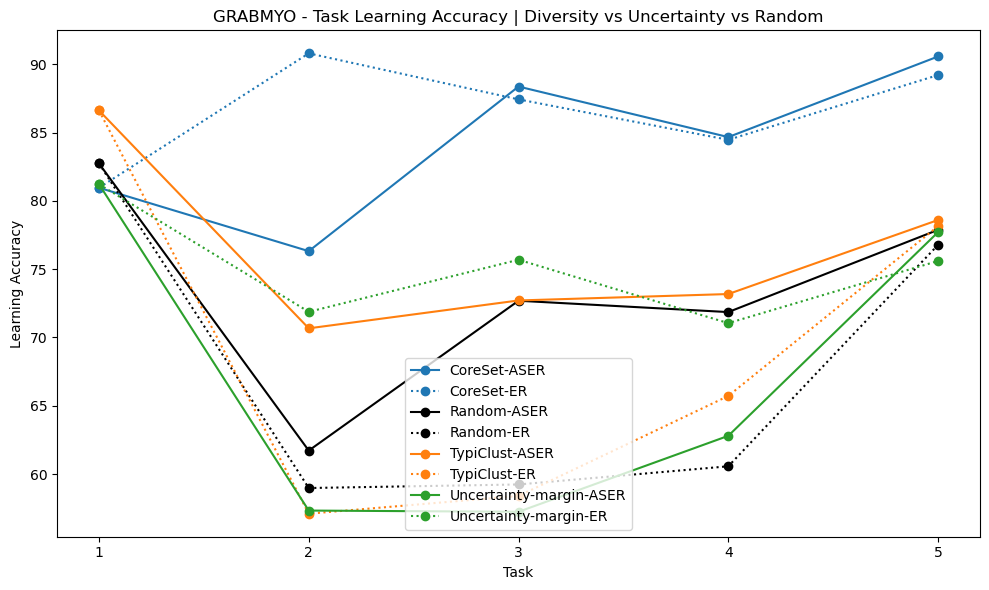

In [17]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Task Learning Accuracy | Diversity vs Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [18]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,82.74,82.74,82.93,82.93
1,62.42,64.05,62.42,65.97
2,58.27,54.47,50.71,55.22
3,50.69,52.32,46.91,51.18
4,49.79,51.25,46.72,49.38


In [19]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,82.74,82.74,82.93,82.93
1,61.72,58.98,68.11,73.26
2,72.69,59.24,72.77,73.84
3,71.86,60.57,73.55,73.75
4,77.88,76.78,82.29,80.99


# Uncertainty Summary

In [20]:
acc_multiple_dataset_multiple_run = pu.get_multiple_al_methods_summary(filtered_files)
results_df = pu.ger_multiple_methods_summary_df(acc_multiple_dataset_multiple_run)
results_df.columns

AttributeError: module 'process_utils' has no attribute 'ger_multiple_methods_summary_df'

In [ ]:
results_df = results_df[['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error']]

method_filter = ['TypiClust', 'CoreSet', 'Random', 'Kmeans-PPP']
results_df = results_df[results_df['Method'].apply(lambda x: any(mf in x for mf in method_filter))]

concat_df = pd.concat([results_df, tscil_results[DATASET]])
concat_df

,Method,Avg End Acc,Avg End Acc error,Avg End Fgt,Avg End Fgt error,Avg Cur Acc,Avg Cur Acc error
8,TypiClust_ER,54.89,4.37,22.40,13.98,69.20,17.75
9,TypiClust_ASER,52.91,3.86,29.80,15.95,76.35,15.23
10,TypiClustLimit_ER,54.11,4.54,21.99,11.46,68.14,18.75
11,TypiClustLimit_ASER,51.33,3.45,21.85,20.24,63.11,25.01
12,Random_ER,51.25,6.71,23.99,15.95,67.66,21.24
13,Random_ASER,49.79,7.54,31.38,12.70,73.38,11.75
16,CoreSet_ER,44.09,4.36,53.11,5.90,86.57,3.80
17,CoreSet_ASER,41.19,5.92,53.85,14.72,84.18,9.33
18,CoreSetProb_ER,54.64,3.61,34.82,6.73,82.21,7.44
19,CoreSetProb_ASER,52.80,3.82,35.13,10.52,80.08,10.19


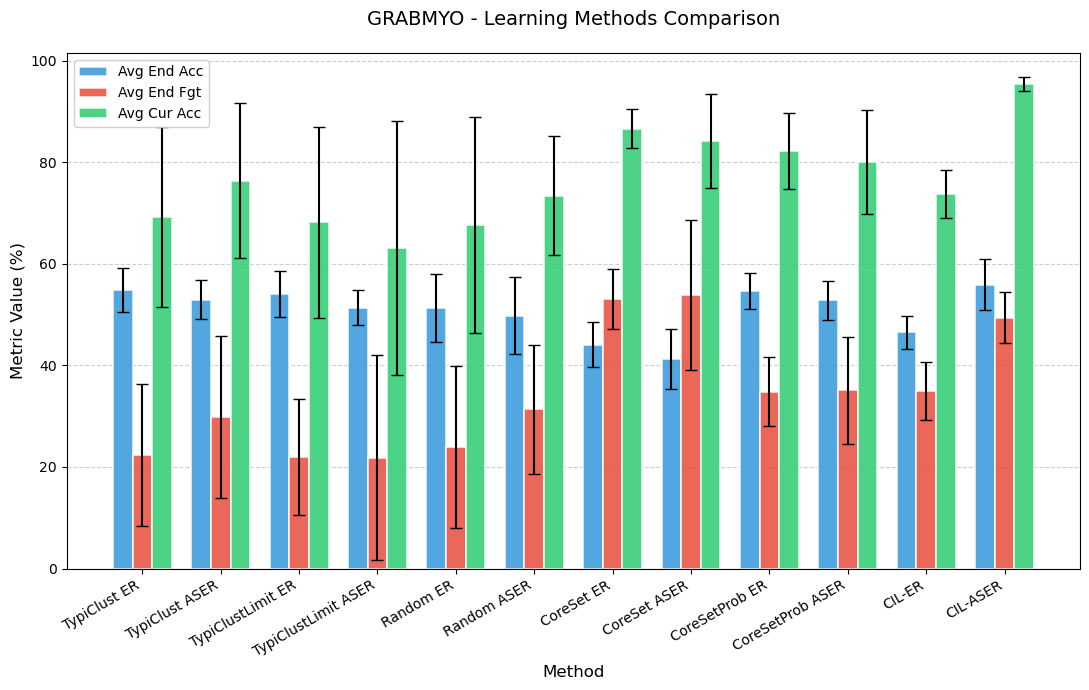

In [ ]:
pu.plot_score_values(concat_df, DATASET, 'best')

# summary

In [21]:
summary = pu.get_multiple_al_methods_summary(filtered_files)
summary_df = pu.get_multiple_methods_summary_df(summary)

filter = [m for m in summary_df['Method'].values if 'typiclust' or m.lower() in 'coreset' in m.lower() or 'random' in m.lower()]
summary_df = summary_df[summary_df['Method'].isin(filter)]